### **🔄 BatchNormalization**

`BatchNormalization` es una capa que **normaliza las activaciones** de la red durante el entrenamiento. Estabiliza y acelera el aprendizaje al mantener la media cercana a 0 y la desviación estándar cercana a 1 por cada mini-lote. 

**Beneficios:**
- Entrenamiento más rápido (epochs) y estable.
- Reducción del riesgo de sobreajuste.
- Permite usar tasas de aprendizaje más altas.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, Input

In [2]:
# Cargar imagen desde URL
url = 'https://labicicleta.net/escuela/wp-content/uploads/BICICLETA_VS_AUTOMOVIL-.jpg'
resp = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
image = cv2.imdecode(image, cv2.IMREAD_COLOR)

In [3]:
# Convertir a escala de grises
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Redimensionar para que no sea muy grande
gray_resized = cv2.resize(gray, (128, 128))

# Normalizar y preparar para el modelo
gray_input = gray_resized.astype("float32") / 255.0
gray_input = np.expand_dims(gray_input, axis=(0, -1))  # Shape: (1, 128, 128, 1)

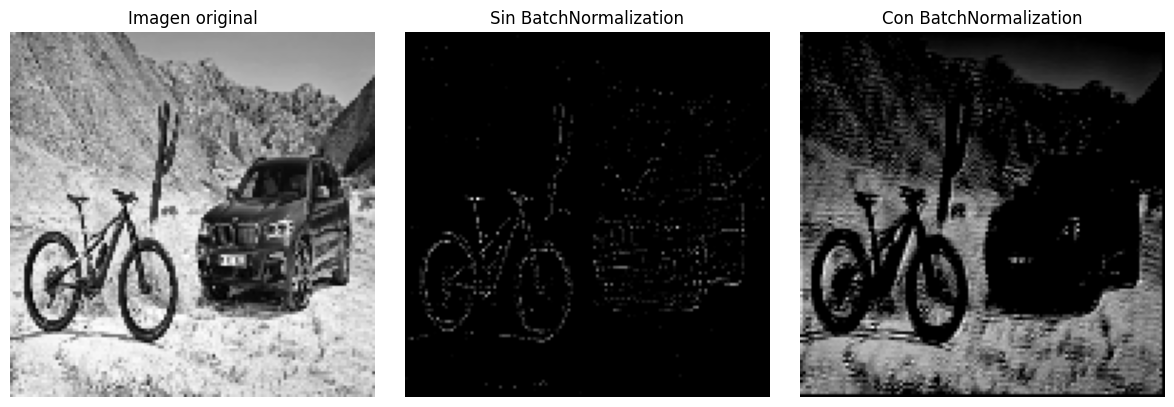

In [18]:
# Modelo sin BatchNormalization
model_no_bn = Sequential([
    Input(shape=(128, 128, 1)),
    Conv2D(1, (3, 3), padding='same'),
    Activation('relu')
])

# Modelo con BatchNormalization
model_bn = Sequential([
    Input(shape=(128, 128, 1)),
    Conv2D(1, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu')
])

# Obtener salidas
output_no_bn = model_no_bn(gray_input, training=True).numpy()[0, :, :, 0]
output_bn = model_bn(gray_input, training=True).numpy()[0, :, :, 0]

# Mostrar resultados
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(gray_resized, cmap='gray')
axs[0].set_title("Imagen original")
axs[1].imshow(output_no_bn, cmap='gray')
axs[1].set_title("Sin BatchNormalization")
axs[2].imshow(output_bn, cmap='gray')
axs[2].set_title("Con BatchNormalization")
for ax in axs:
    ax.axis("off")
plt.tight_layout()
plt.show()


In [19]:
output_no_bn

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [20]:
output_bn

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.38073325, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.22871041, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [1.447314  , 1.1747692 , 1.1624355 , ..., 0.8291514 , 0.31318617,
        0.        ],
       [1.0775187 , 1.0595009 , 0.89613223, ..., 0.28542686, 0.3956933 ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype=float32)

In [21]:
model_no_bn.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 128, 128, 1)    │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 128, 128, 1)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
model_bn.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 1)    │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128, 128, 1)    │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 128, 128, 1)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 12 (48.00 B)

 Non-trainable params: 2 (8.00 B)

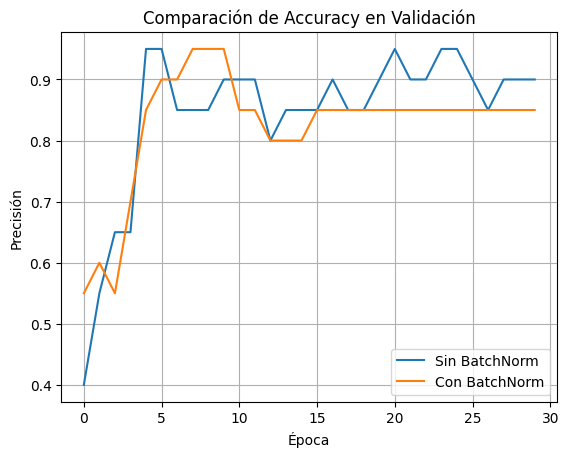

In [29]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, BatchNormalization, Activation, MaxPooling2D
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Cargar datos
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Usar solo 100 ejemplos para sobreajuste intencional
x_train = x_train[:100]
y_train = y_train[:100]

x_test = x_test[:100]
y_test = y_test[:100]

# Normalizar y dar forma
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

def build_model(use_bn=False):
    model = Sequential()
    model.add(Conv2D(32, (3, 3), padding='same', input_shape=(28, 28, 1)))
    if use_bn:
        model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D())
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Entrenar ambos modelos
model_no_bn = build_model(use_bn=False)
model_bn = build_model(use_bn=True)

history_no_bn = model_no_bn.fit(x_train, y_train, epochs=30, validation_split=0.2, verbose=0)
history_bn = model_bn.fit(x_train, y_train, epochs=30, validation_split=0.2, verbose=0)

# Graficar
plt.plot(history_no_bn.history['val_accuracy'], label='Sin BatchNorm')
plt.plot(history_bn.history['val_accuracy'], label='Con BatchNorm')
plt.title('Comparación de Accuracy en Validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)
plt.show()
